## Cifar-10


In [2]:
import torch
import torchvision 
from torchvision import transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter

# Set Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# load the dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Classes: {trainset.classes}")
print(f"Number of classes: {len(trainset.classes)}")

# Get a single sample to understand data structure
sample_img, sample_label = trainset[0]
print(f"\nSample image shape: {sample_img.shape}")
print(f"Sample label: {sample_label} ({trainset.classes[sample_label]})")
print(f"Image dtype: {sample_img.dtype}")
print(f"Pixel value range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")

Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10

Sample image shape: torch.Size([3, 32, 32])
Sample label: 6 (frog)
Image dtype: torch.float32
Pixel value range: [0.000, 1.000]


## Class Distribution Analysis

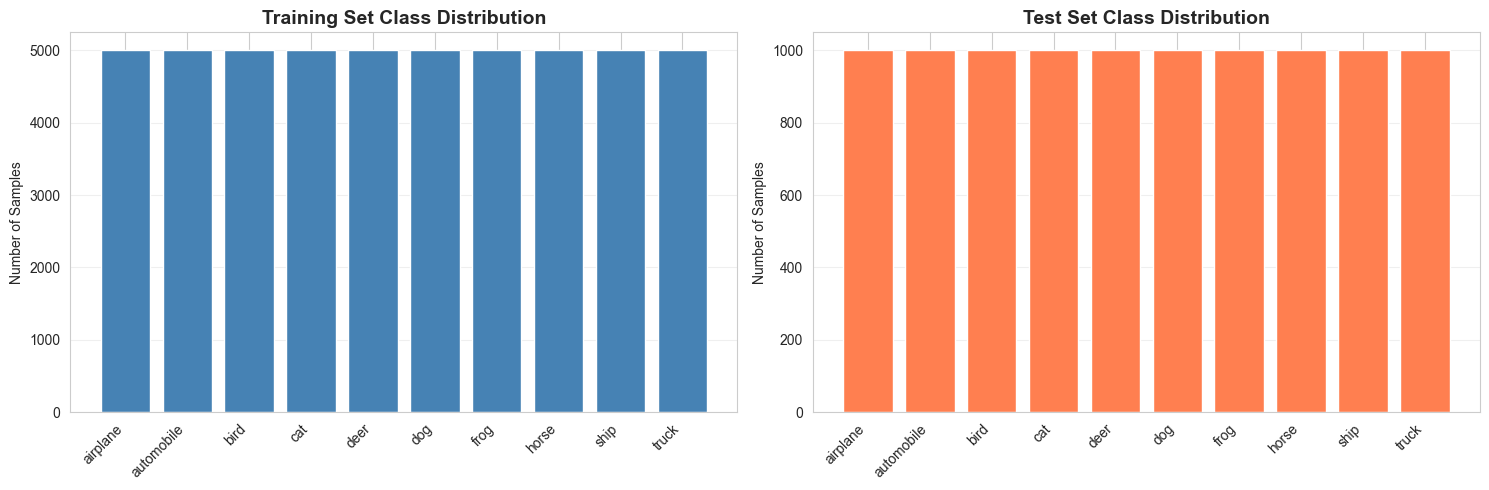


Class Distribution Summary:
airplane    : Train= 5000, Test=1000
automobile  : Train= 5000, Test=1000
bird        : Train= 5000, Test=1000
cat         : Train= 5000, Test=1000
deer        : Train= 5000, Test=1000
dog         : Train= 5000, Test=1000
frog        : Train= 5000, Test=1000
horse       : Train= 5000, Test=1000
ship        : Train= 5000, Test=1000
truck       : Train= 5000, Test=1000


In [3]:
# Class Distributiuon Analysis
train_labels = [label for _, label in trainset]
test_labels  = [label for _, label in testset]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Training set distribution
train_counts = Counter(train_labels)
axes[0].bar(range(10), [train_counts[i] for i in range(10)], color='steelblue')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(trainset.classes, rotation=45, ha='right')
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
test_counts = Counter(test_labels)
axes[1].bar(range(10), [test_counts[i] for i in range(10)], color='coral')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(testset.classes, rotation=45, ha='right')
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nClass Distribution Summary:")
for i, class_name in enumerate(trainset.classes):
    print(f"{class_name:12s}: Train={train_counts[i]:5d}, Test={test_counts[i]:4d}")


# Sample Images from Each class

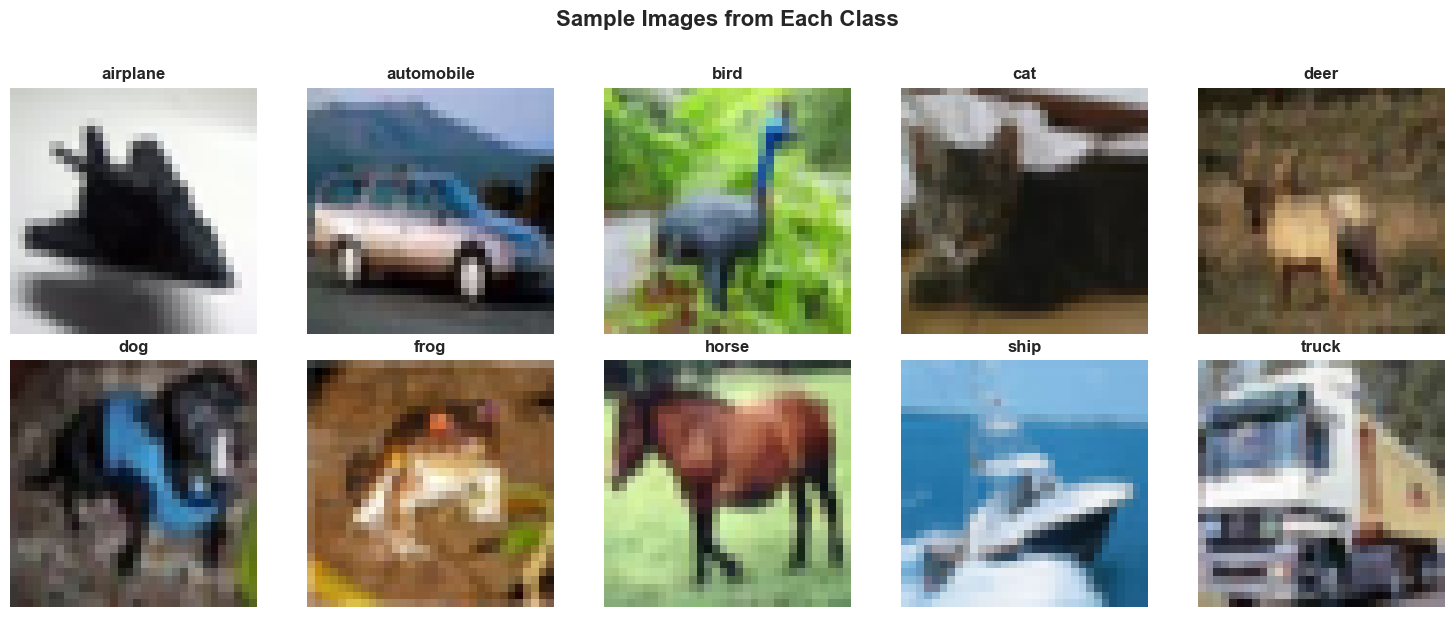

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Find first image of this class
    idx = train_labels.index(i)
    img, label = trainset[idx]
    
    # Convert tensor to numpy and transpose to (H, W, C)
    img_np = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_np)
    axes[i].set_title(f'{trainset.classes[label]}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Multiple Samples per Class


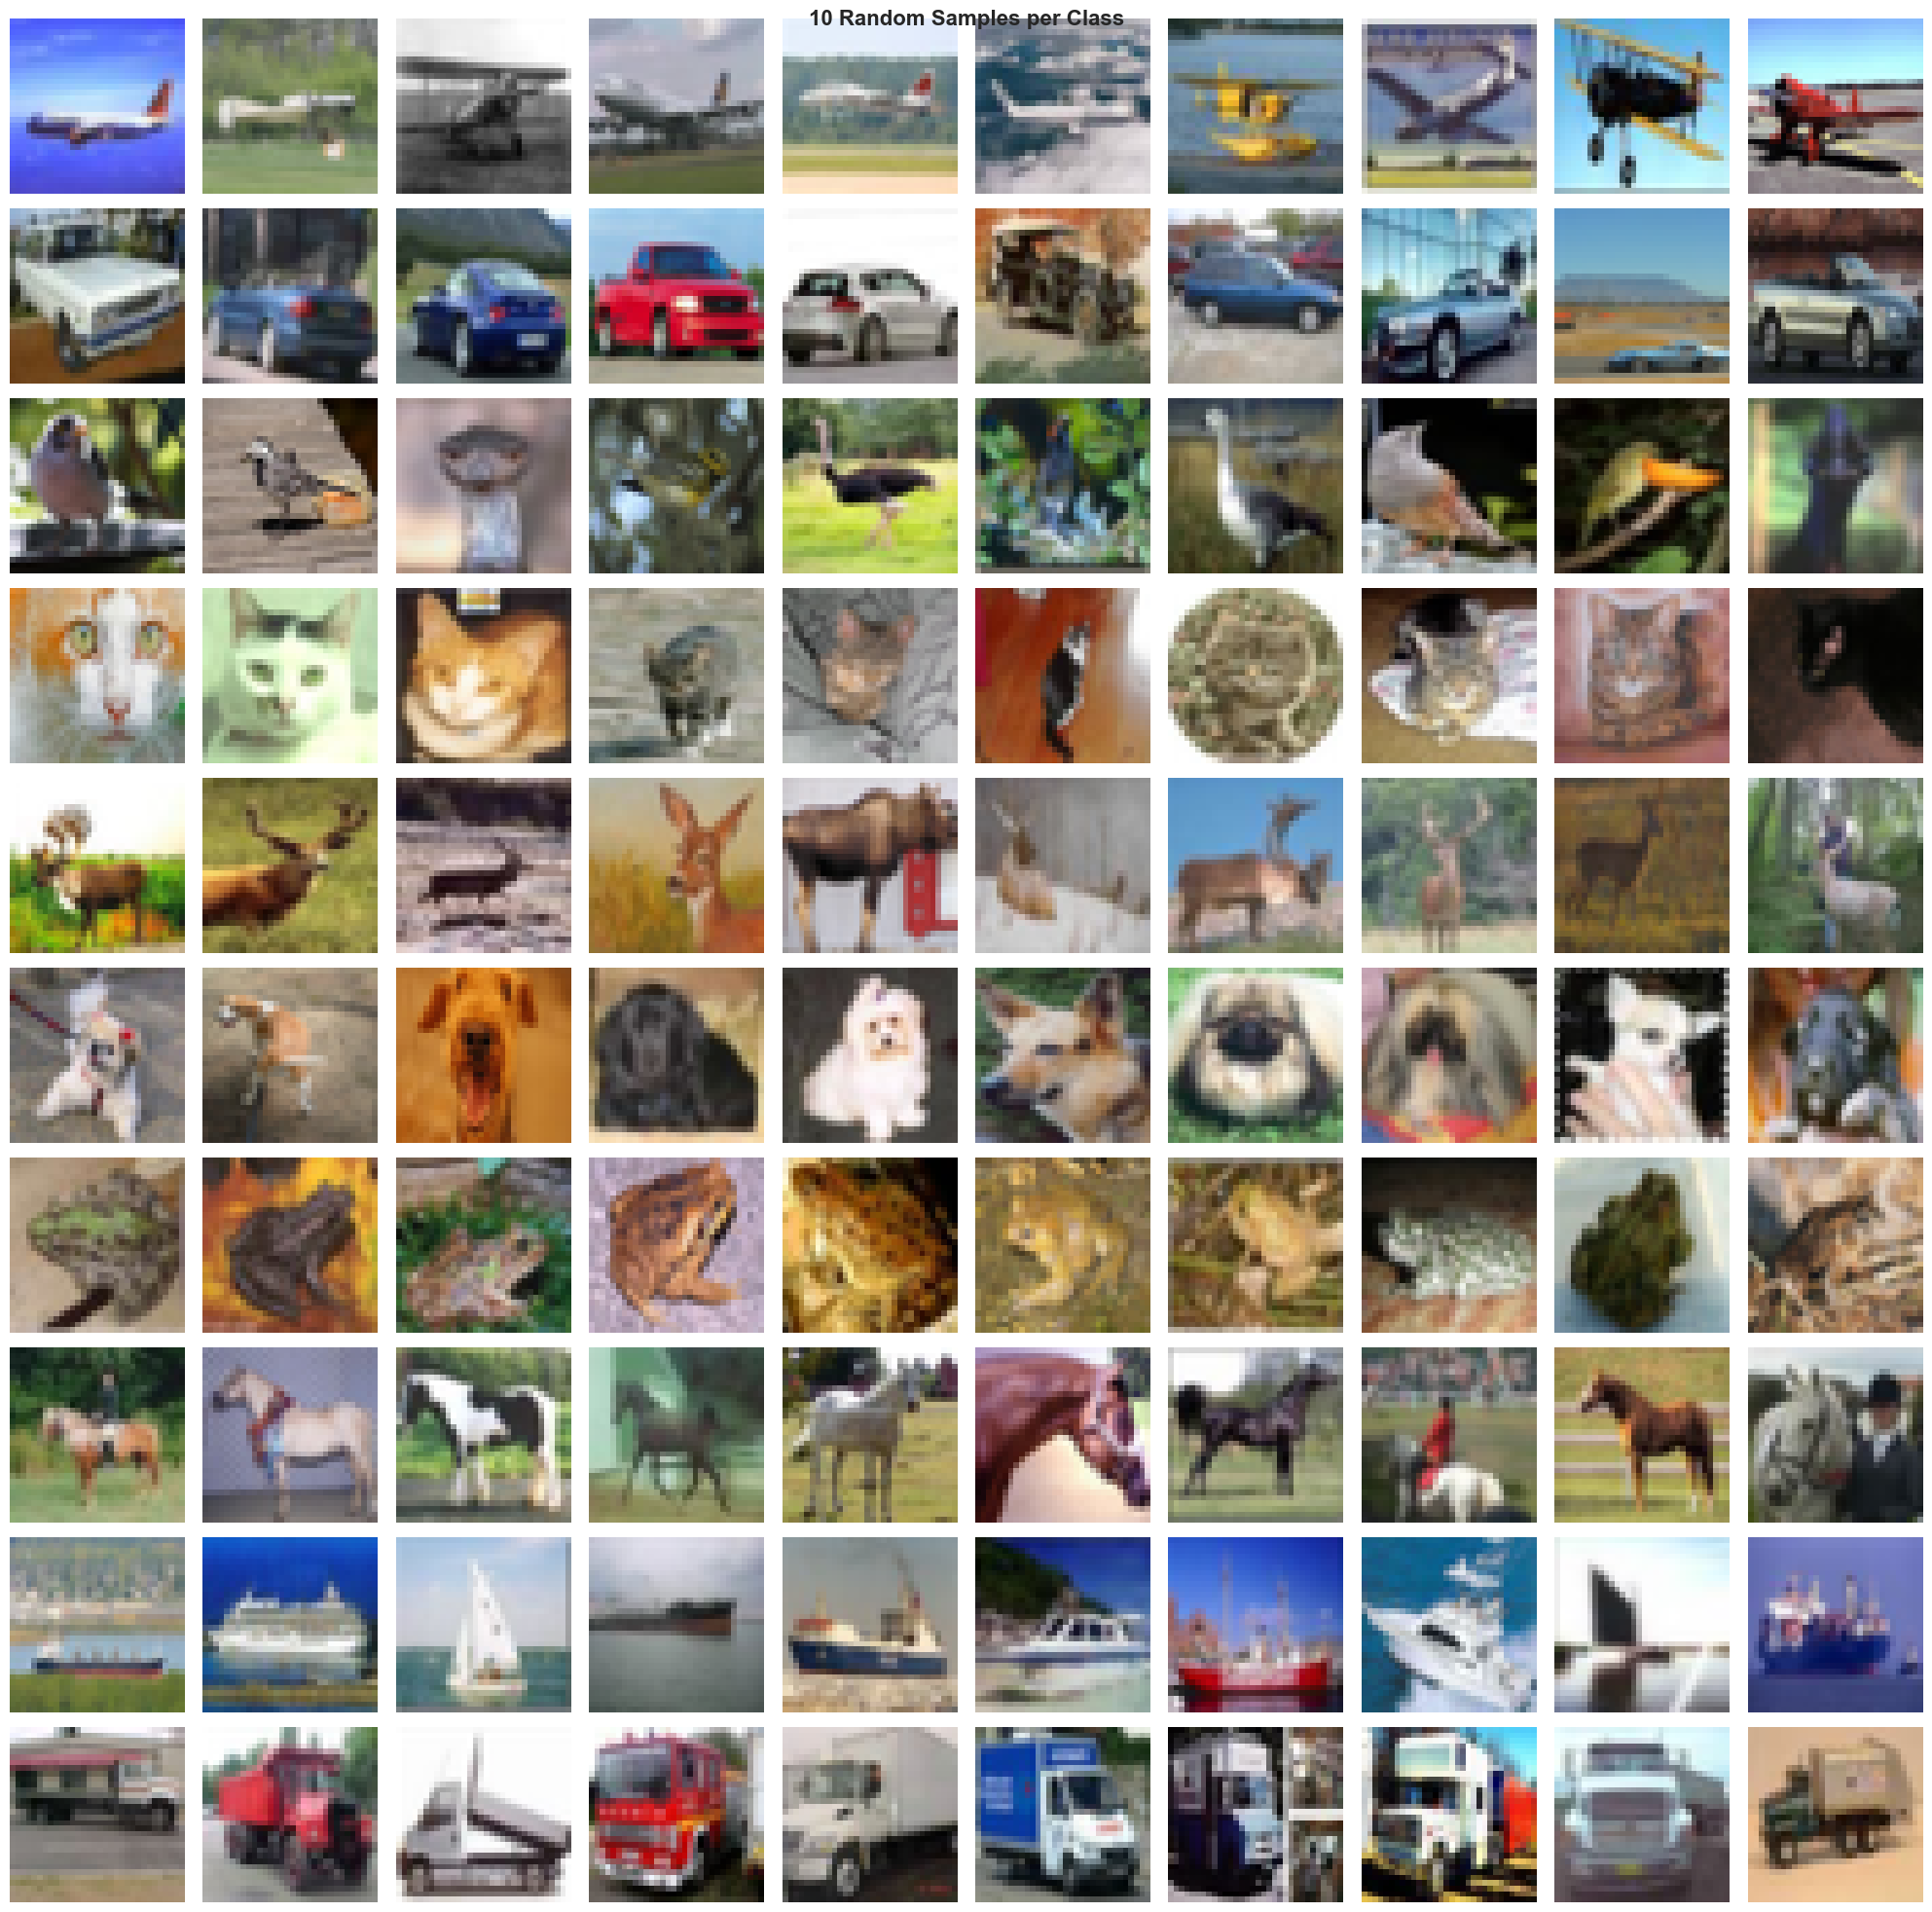

In [5]:
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

for class_idx in range(10):
    # Get indices of all images from this class
    class_indices = [i for i, label in enumerate(train_labels) if label == class_idx]
    
    # Select 10 random samples
    random_indices = np.random.choice(class_indices, 10, replace=False)
    
    for col, idx in enumerate(random_indices):
        img, _ = trainset[idx]
        img_np = img.permute(1, 2, 0).numpy()
        
        axes[class_idx, col].imshow(img_np)
        axes[class_idx, col].axis('off')
        
        if col == 0:
            axes[class_idx, col].set_ylabel(trainset.classes[class_idx], 
                                           fontsize=12, fontweight='bold', rotation=0, 
                                           ha='right', va='center')

plt.suptitle('10 Random Samples per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Pixel Value Distribution Analysis
##### Sample 1000 random images for analysis


Channel Statistics (from 1000 random samples):
Red   Channel - Mean: 0.4904, Std: 0.2473
Green Channel - Mean: 0.4763, Std: 0.2444
Blue  Channel - Mean: 0.4400, Std: 0.2610


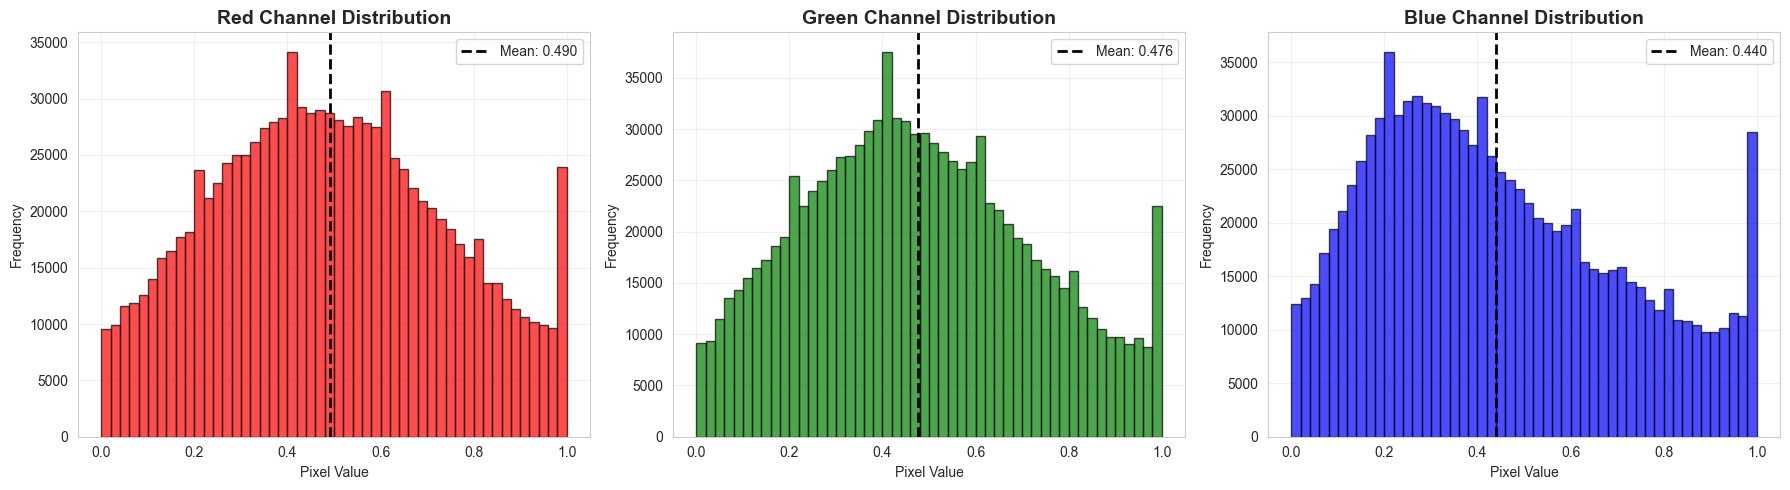

In [11]:
sample_indices = np.random.choice(len(trainset), 1000, replace=False)
sampled_images = torch.stack([trainset[i][0] for i in sample_indices])

# Calculate statistics per channel
mean_per_channel = sampled_images.mean(dim=[0, 2, 3])
std_per_channel = sampled_images.std(dim=[0, 2, 3])

print("Channel Statistics (from 1000 random samples):")
print(f"Red   Channel - Mean: {mean_per_channel[0]:.4f}, Std: {std_per_channel[0]:.4f}")
print(f"Green Channel - Mean: {mean_per_channel[1]:.4f}, Std: {std_per_channel[1]:.4f}")
print(f"Blue  Channel - Mean: {mean_per_channel[2]:.4f}, Std: {std_per_channel[2]:.4f}")

# Plot distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

for i in range(3):
    channel_data = sampled_images[:, i, :, :].flatten().numpy()
    axes[i].hist(channel_data, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{channel_names[i]} Channel Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(mean_per_channel[i], color='black', linestyle='--', 
                   linewidth=2, label=f'Mean: {mean_per_channel[i]:.3f}')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## IMage Brightness Analysis
#### Calculate Average Brightness per image

C:\Users\hp\AppData\Local\Temp\ipykernel_10636\2011055786.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([brightness_by_class[i] for i in range(10)],


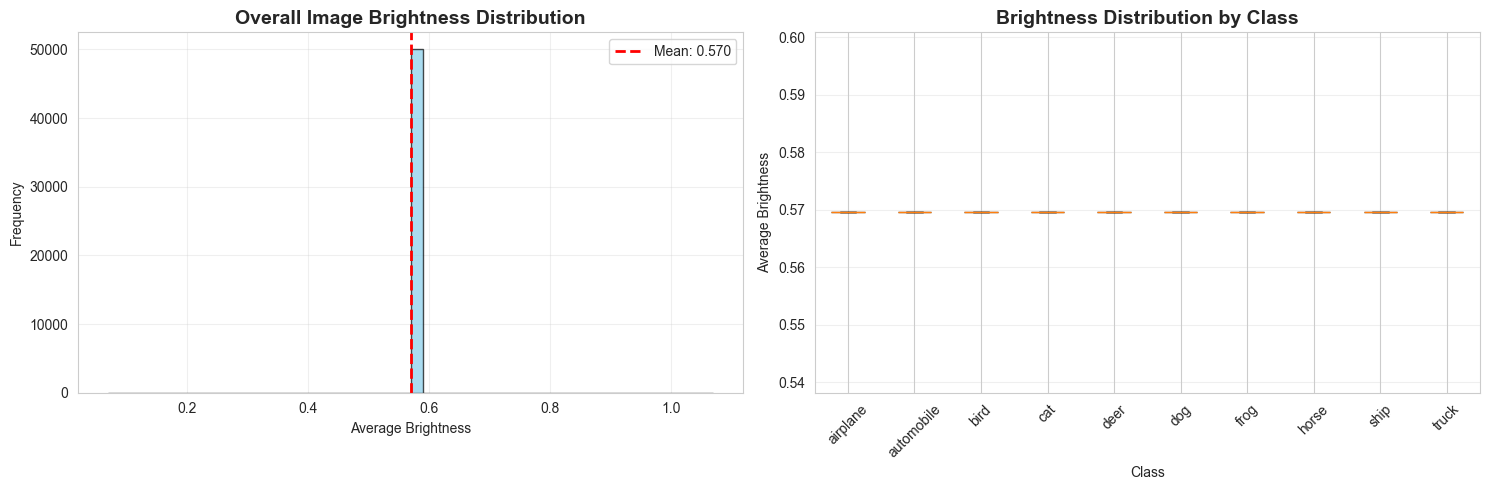

In [7]:
brightness_train = []
for image, label in trainset:
    brightness = img.mean().item()
    brightness_train.append((brightness, label))

brightness_values = [b for b, _ in brightness_train]
brightness_labels = [l for _, l in brightness_train]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall brightness distribution
axes[0].hist(brightness_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Overall Image Brightness Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Brightness')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(brightness_values), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(brightness_values):.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Brightness by class
brightness_by_class = {i: [] for i in range(10)}
for brightness, label in brightness_train:
    brightness_by_class[label].append(brightness)

axes[1].boxplot([brightness_by_class[i] for i in range(10)], 
                labels=trainset.classes, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_title('Brightness Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Average Brightness')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Image Variance Analysis (Texture Complexity)

C:\Users\hp\AppData\Local\Temp\ipykernel_10636\2050342768.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([variance_by_class[i] for i in range(10)],


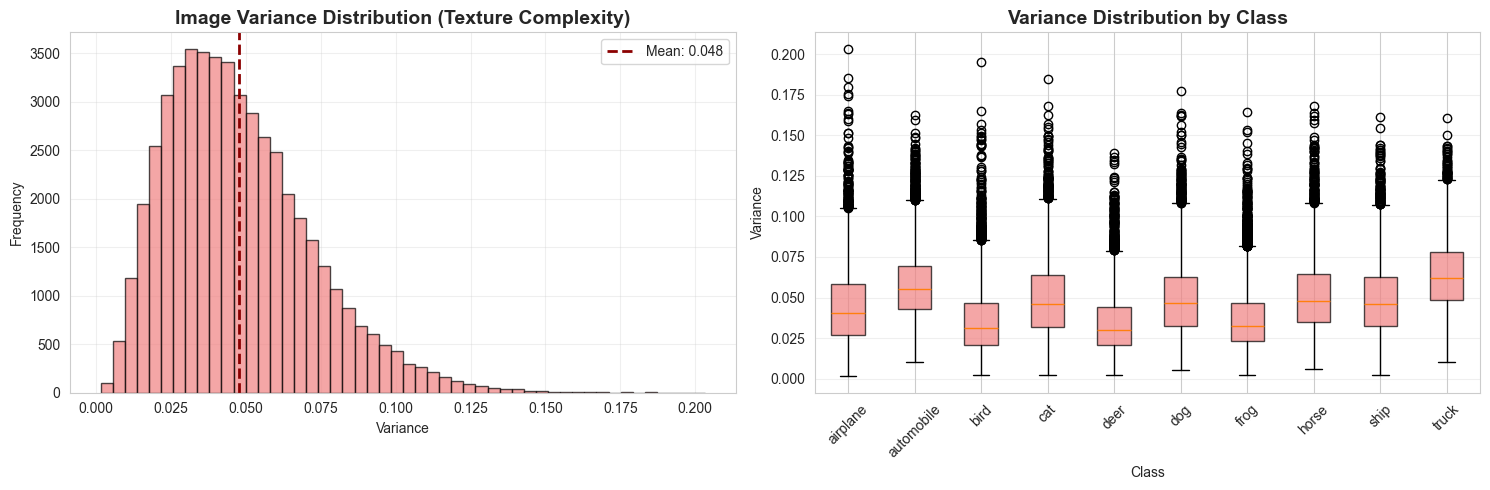

In [8]:
variance_train = []
for img, label in trainset:
    variance = img.var().item()
    variance_train.append((variance, label))

variance_values = [v for v, _ in variance_train]
variance_labels = [l for _, l in variance_train]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall variance distribution
axes[0].hist(variance_values, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Variance Distribution (Texture Complexity)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(variance_values), color='darkred', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(variance_values):.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Variance by class
variance_by_class = {i: [] for i in range(10)}
for variance, label in variance_train:
    variance_by_class[label].append(variance)

axes[1].boxplot([variance_by_class[i] for i in range(10)], 
                labels=trainset.classes, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7))
axes[1].set_title('Variance Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Variance')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Data Augmentation Visualization

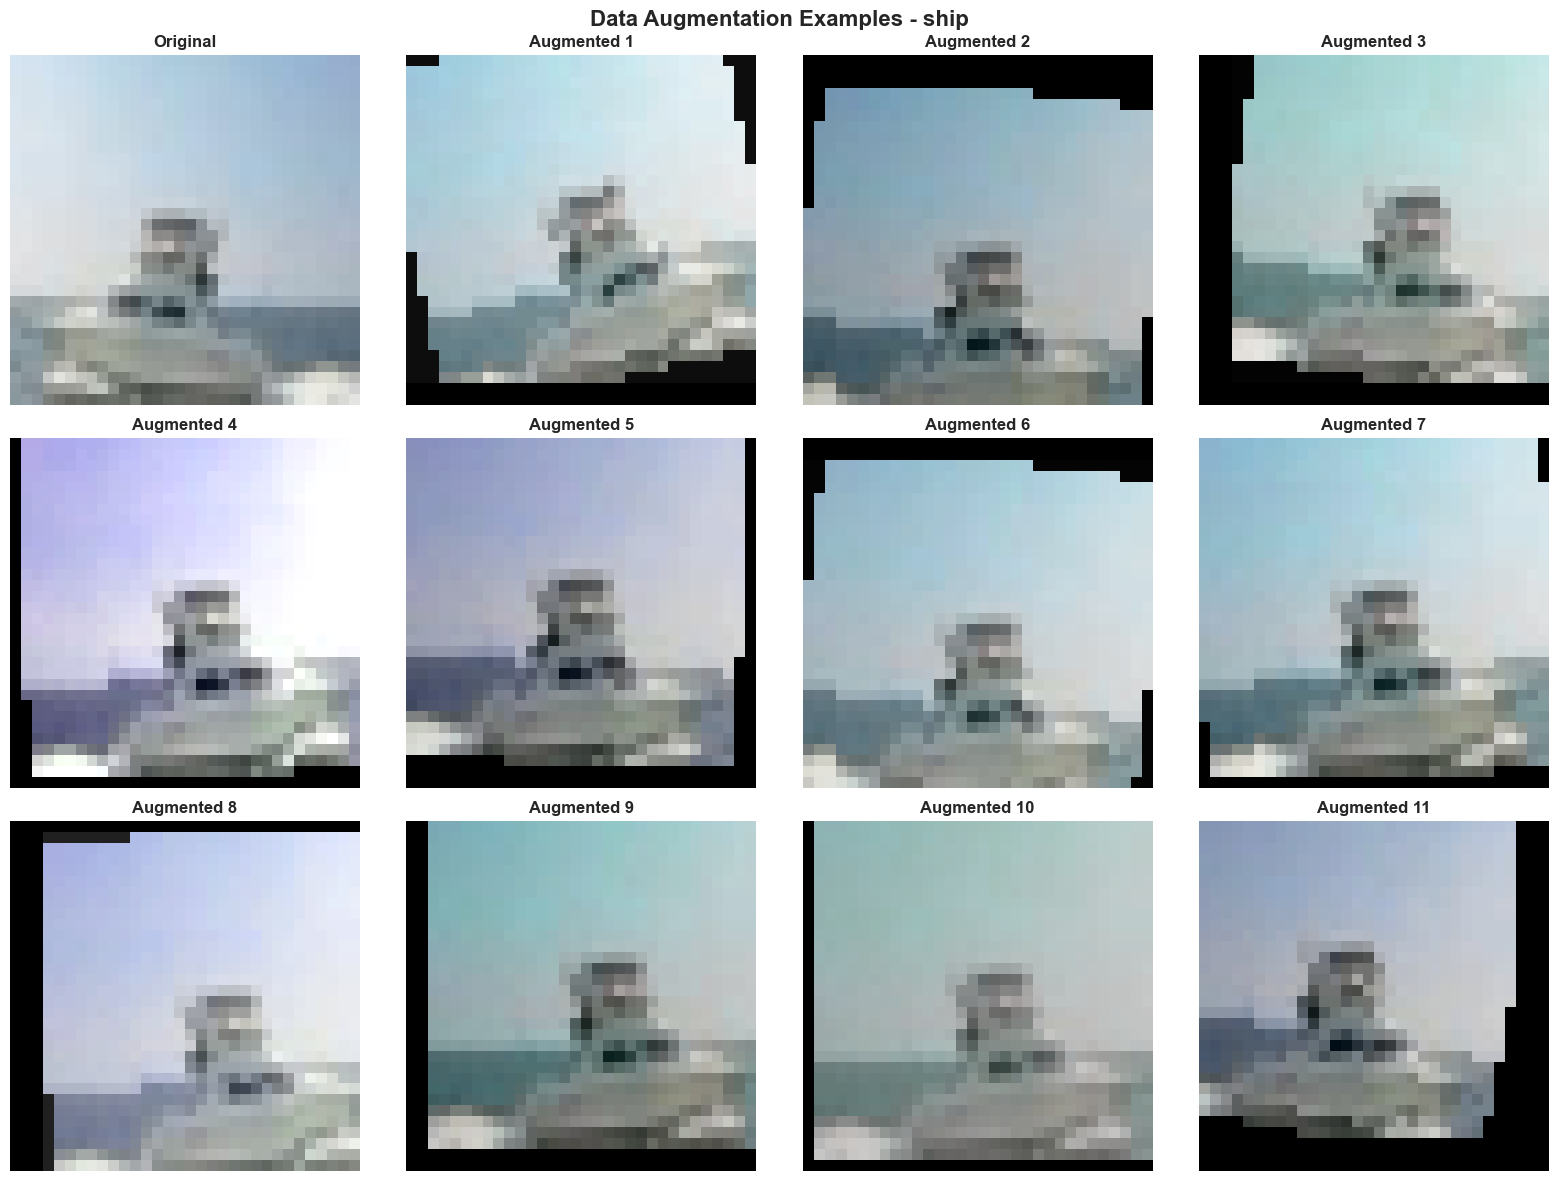

In [9]:
from torchvision import transforms

# Define augmentation pipeline
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

# Get a sample image
sample_img, sample_label = trainset[100]

# Create augmented versions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Original image
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Apply different augmentations
for i in range(1, 12):
    # Convert to PIL, apply augmentation, convert back to tensor
    pil_img = transforms.ToPILImage()(sample_img)
    augmented = augmentation(pil_img)
    augmented_tensor = transforms.ToTensor()(augmented)
    
    axes[i].imshow(augmented_tensor.permute(1, 2, 0).numpy())
    axes[i].set_title(f'Augmented {i}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f'Data Augmentation Examples - {trainset.classes[sample_label]}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Summary Stats

In [12]:
summary_data = {
    'Metric': ['Total Training Samples', 'Total Test Samples', 'Number of Classes', 
               'Image Height', 'Image Width', 'Number of Channels',
               'Min Pixel Value', 'Max Pixel Value',
               'Mean Brightness', 'Mean Variance',
               'Samples per Class (Train)', 'Samples per Class (Test)'],
    'Value': [len(trainset), len(testset), len(trainset.classes),
              32, 32, 3,
              0.0, 1.0,
              f"{np.mean(brightness_values):.4f}", f"{np.mean(variance_values):.4f}",
              5000, 1000]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*50)
print("CIFAR-10 DATASET SUMMARY")
print("="*50)
print(df_summary.to_string(index=False))
print("="*50)

print("\nNormalization Values (for training):")
print(f"Mean: [{mean_per_channel[0]:.4f}, {mean_per_channel[1]:.4f}, {mean_per_channel[2]:.4f}]")
print(f"Std:  [{std_per_channel[0]:.4f}, {std_per_channel[1]:.4f}, {std_per_channel[2]:.4f}]")


CIFAR-10 DATASET SUMMARY
                   Metric  Value
   Total Training Samples  50000
       Total Test Samples  10000
        Number of Classes     10
             Image Height     32
              Image Width     32
       Number of Channels      3
          Min Pixel Value    0.0
          Max Pixel Value    1.0
          Mean Brightness 0.5695
            Mean Variance 0.0476
Samples per Class (Train)   5000
 Samples per Class (Test)   1000

Normalization Values (for training):
Mean: [0.4904, 0.4763, 0.4400]
Std:  [0.2473, 0.2444, 0.2610]
